**Polarization-RL: Adaptive Policy Strategies in Dynamic Opinion Environments**


Train an RL agent to manage interventions (e.g., media messaging, education campaigns, policy signals) in a polarized society, where each action affects the future distribution of ideological positions.

In [1]:
import numpy as np
!pip install 'shimmy>=2.0'
import gym
from gym import spaces
import matplotlib.pyplot as plt
!pip install stable-baselines3[extra]
from stable_baselines3 import PPO



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.5/184.5 kB 10.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 700  |
|    iterations      | 1    |
|    time_elapsed    | 2    |
|    total_timesteps | 2048 |
-----------------------------
----------------------------------------
| time/                   |            |
|    fps                  | 522        |
|    iterations           | 2          |
|    time_elapsed         | 7          |
|    total_timesteps      | 4096       |
| train/                  |            |
|    approx_kl            | 0.01242438 |
|    clip_fraction        | 0.184      |
|    clip_range           | 0.2        |
|    entropy_loss         | -1.09      |
|    explained_variance   | -1.17      |
|    learning_rate        | 0.0003     |
|    loss                 | -0.0109    |
|    n_updates            | 10         |
|    policy_gradient_loss | -0.0182    |
|    value_loss           | 0.000925   |
----------------------------------------
-----------------------------------------
| time/   

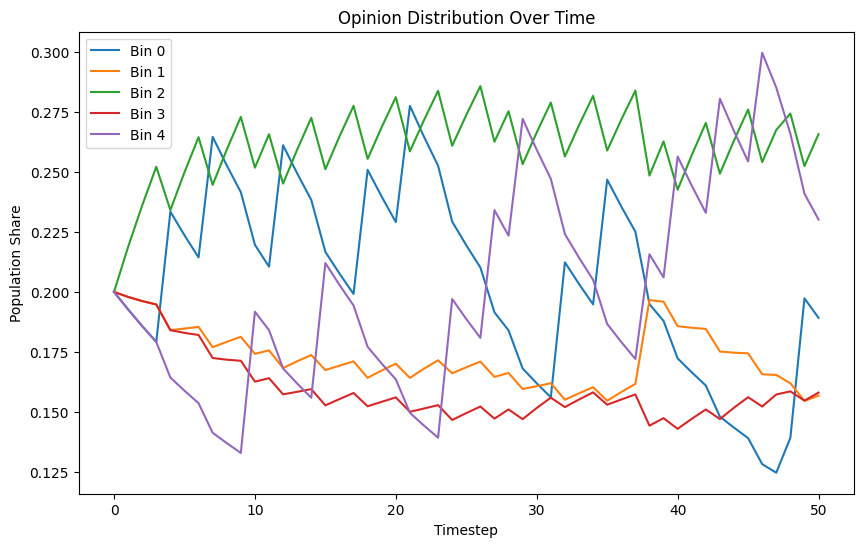

In [2]:
# ---- Step 1: Define Advanced Environment ---- #

class PolarizationEnv(gym.Env):
    """Advanced Environment for Polarization Dynamics with Feedback"""

    def __init__(self, population_size=1000):
        super(PolarizationEnv, self).__init__()

        self.population_size = population_size
        self.num_bins = 5  # Far left, left, center, right, far right

        # Opinion distribution: bins of ideological positions
        self.opinion_distribution = np.ones(self.num_bins) / self.num_bins

        # Action space: 0 = Moderate messaging, 1 = Provocative messaging, 2 = Fact-checking campaign
        self.action_space = spaces.Discrete(3)

        # Observation space: normalized opinion distribution
        self.observation_space = spaces.Box(low=0, high=1, shape=(self.num_bins,), dtype=np.float32)

        # Dynamics parameters
        self.inertia = 0.85  # Opinion inertia (tendency to stick to current opinions)
        self.influence_strength = 0.1  # Peer influence strength
        self.external_shock_prob = 0.05  # Chance of random external shock

        self.history = []  # For tracking evolution

    def step(self, action):
        self._apply_action(action)
        self._simulate_opinion_shift()
        self._external_shock()

        polarization_index = np.var(self.opinion_distribution)
        reward = -polarization_index  # Less variance is better

        done = False

        info = {"polarization_index": polarization_index}

        self.history.append(self.opinion_distribution.copy())

        return self.opinion_distribution.astype(np.float32), reward, done, info

    def reset(self):
        self.opinion_distribution = np.ones(self.num_bins) / self.num_bins
        self.history = [self.opinion_distribution.copy()]
        return self.opinion_distribution.astype(np.float32)

    def render(self, mode='human'):
        plt.figure(figsize=(8, 4))
        plt.bar(range(self.num_bins), self.opinion_distribution)
        plt.xlabel('Ideological Position')
        plt.ylabel('Population Share')
        plt.title('Opinion Distribution')
        plt.show()

    def render_history(self):
        history = np.array(self.history)
        plt.figure(figsize=(10, 6))
        for i in range(self.num_bins):
            plt.plot(history[:, i], label=f'Bin {i}')
        plt.xlabel('Timestep')
        plt.ylabel('Population Share')
        plt.title('Opinion Distribution Over Time')
        plt.legend()
        plt.show()

    def _apply_action(self, action):
        if action == 0:  # Moderate messaging
            self.shift_target = 2  # Center bin
            self.shift_intensity = 0.02
        elif action == 1:  # Provocative messaging
            self.shift_target = np.random.choice([0, 4])  # Push to extremes
            self.shift_intensity = 0.07
        elif action == 2:  # Fact-checking campaign
            self.shift_target = 2  # Center bin
            self.shift_intensity = 0.04

    def _simulate_opinion_shift(self):
        new_distribution = self.opinion_distribution * self.inertia

        # Peer influence: smooth distribution slightly toward average
        peer_influence = np.convolve(self.opinion_distribution, [0.25, 0.5, 0.25], mode='same')
        new_distribution += peer_influence * self.influence_strength

        # Action-driven shift: move mass toward shift_target
        shift = np.zeros(self.num_bins)
        shift[self.shift_target] = self.shift_intensity
        new_distribution += shift

        # Normalize
        self.opinion_distribution = new_distribution / np.sum(new_distribution)

    def _external_shock(self):
        if np.random.rand() < self.external_shock_prob:
            shock_target = np.random.choice(self.num_bins)
            shock_intensity = np.random.uniform(0.02, 0.1)
            self.opinion_distribution[shock_target] += shock_intensity
            # Normalize
            self.opinion_distribution /= np.sum(self.opinion_distribution)


# ---- Step 2: Train Agent ---- #

env = PolarizationEnv()
model = PPO('MlpPolicy', env, verbose=1)
model.learn(total_timesteps=30000)
model.save("ppo_polarization_v2")

# ---- Step 3: Test and Visualize ---- #

obs = env.reset()
for _ in range(50):
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, done, info = env.step(action)
    print(f"Reward: {reward:.4f} | Polarization Index: {info['polarization_index']:.4f}")

# Plot opinion distribution evolution
env.render_history()


This plot shows:

* Decision-dependent dynamics are in play.

* The environment is not passive — it reacts and creates feedback loops.

* You are seeing emergent behavior.

Agent's decisions are influencing the population, but the opinion distribution isn't stabilizing perfectly — it’s oscillating.
This fits exactly the following question: *what happens when decisions feed back and affect the environment?*


The agent tries to push to center (Bin 2), but the environment "pushes back" — maybe due to randomness, opinion inertia, or external shocks.

Opinions don't settle but cycle — which is common in polarized dynamics models!

This "cycling" behavior is known in opinion dynamics as *limit cycles* — not static equilibrium, but perpetual motion of opinions across the spectrum.

Next Steps:
* Plot the agent’s decisions alongside this graph to see if the oscillations  match policy shifts, answering the following questions:
  * When the agent chooses provocative, do the extremes increase?
  * When the agent chooses moderate, does the center stabilize?

* run constant strategies ("always moderate", "always provoke") to compare.

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 334  |
|    iterations      | 1    |
|    time_elapsed    | 6    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 281         |
|    iterations           | 2           |
|    time_elapsed         | 14          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.012448212 |
|    clip_fraction        | 0.131       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.09       |
|    explained_variance   | -1.03       |
|    learning_rate        | 0.0003      |
|    loss                 | 0.00109     |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00819    |
|    value_loss           | 0.00145     |
-----------------------------------------
----------------------------------

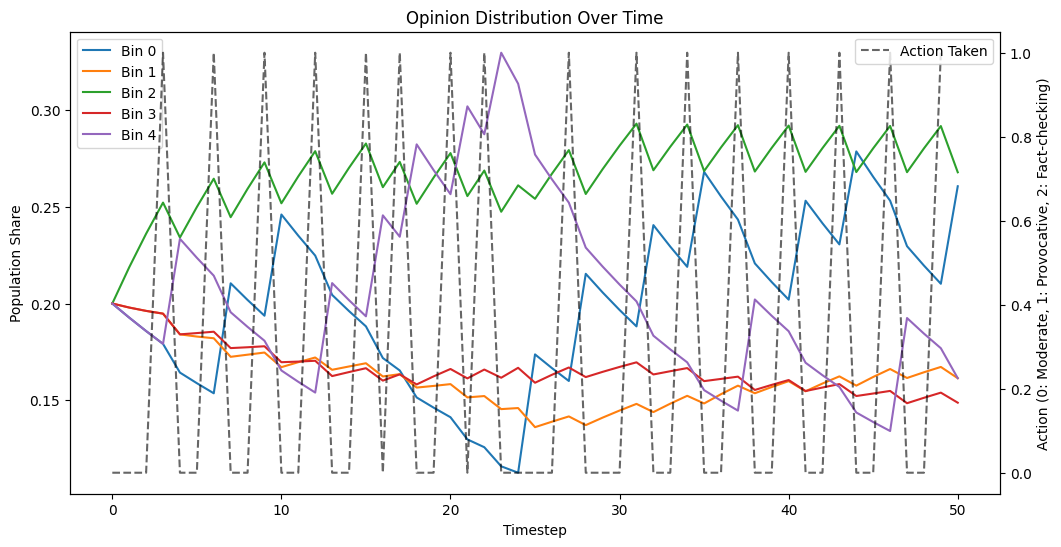


Running Always Moderate Strategy (Action 0)...
Reward: -0.0001 | Polarization Index: 0.0001 | Action: 0
Reward: -0.0003 | Polarization Index: 0.0003 | Action: 0
Reward: -0.0007 | Polarization Index: 0.0007 | Action: 0
Reward: -0.0012 | Polarization Index: 0.0012 | Action: 0
Reward: -0.0018 | Polarization Index: 0.0018 | Action: 0
Reward: -0.0023 | Polarization Index: 0.0023 | Action: 0
Reward: -0.0029 | Polarization Index: 0.0029 | Action: 0
Reward: -0.0036 | Polarization Index: 0.0036 | Action: 0
Reward: -0.0043 | Polarization Index: 0.0043 | Action: 0
Reward: -0.0050 | Polarization Index: 0.0050 | Action: 0
Reward: -0.0057 | Polarization Index: 0.0057 | Action: 0
Reward: -0.0064 | Polarization Index: 0.0064 | Action: 0
Reward: -0.0071 | Polarization Index: 0.0071 | Action: 0
Reward: -0.0078 | Polarization Index: 0.0078 | Action: 0
Reward: -0.0084 | Polarization Index: 0.0084 | Action: 0
Reward: -0.0090 | Polarization Index: 0.0090 | Action: 0
Reward: -0.0096 | Polarization Index: 0.

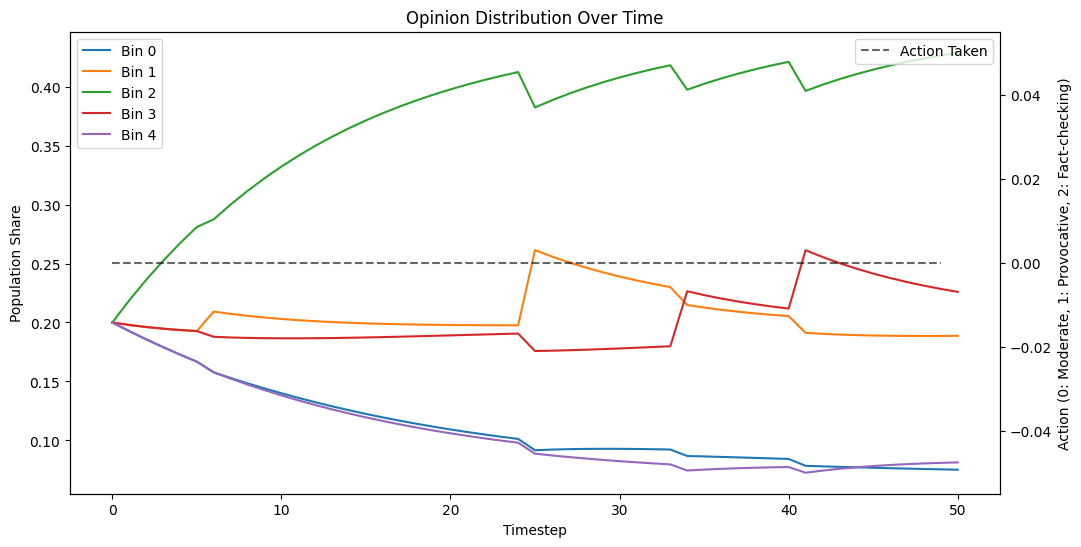


Running Always Provocative Strategy (Action 1)...
Reward: -0.0007 | Polarization Index: 0.0007 | Action: 1
Reward: -0.0008 | Polarization Index: 0.0008 | Action: 1
Reward: -0.0021 | Polarization Index: 0.0021 | Action: 1
Reward: -0.0043 | Polarization Index: 0.0043 | Action: 1
Reward: -0.0071 | Polarization Index: 0.0071 | Action: 1
Reward: -0.0055 | Polarization Index: 0.0055 | Action: 1
Reward: -0.0055 | Polarization Index: 0.0055 | Action: 1
Reward: -0.0067 | Polarization Index: 0.0067 | Action: 1
Reward: -0.0075 | Polarization Index: 0.0075 | Action: 1
Reward: -0.0092 | Polarization Index: 0.0092 | Action: 1
Reward: -0.0116 | Polarization Index: 0.0116 | Action: 1
Reward: -0.0105 | Polarization Index: 0.0105 | Action: 1
Reward: -0.0126 | Polarization Index: 0.0126 | Action: 1
Reward: -0.0151 | Polarization Index: 0.0151 | Action: 1
Reward: -0.0179 | Polarization Index: 0.0179 | Action: 1
Reward: -0.0210 | Polarization Index: 0.0210 | Action: 1
Reward: -0.0241 | Polarization Index:

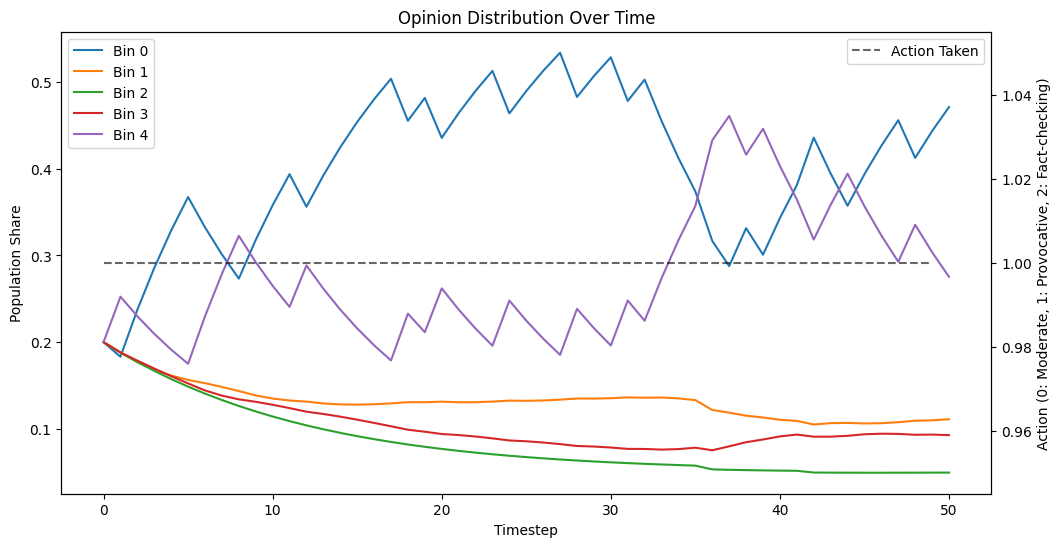


Running Always Fact-checking Strategy (Action 2)...
Reward: -0.0003 | Polarization Index: 0.0003 | Action: 2
Reward: -0.0011 | Polarization Index: 0.0011 | Action: 2
Reward: -0.0023 | Polarization Index: 0.0023 | Action: 2
Reward: -0.0034 | Polarization Index: 0.0034 | Action: 2
Reward: -0.0049 | Polarization Index: 0.0049 | Action: 2
Reward: -0.0065 | Polarization Index: 0.0065 | Action: 2
Reward: -0.0082 | Polarization Index: 0.0082 | Action: 2
Reward: -0.0099 | Polarization Index: 0.0099 | Action: 2
Reward: -0.0116 | Polarization Index: 0.0116 | Action: 2
Reward: -0.0133 | Polarization Index: 0.0133 | Action: 2
Reward: -0.0149 | Polarization Index: 0.0149 | Action: 2
Reward: -0.0116 | Polarization Index: 0.0116 | Action: 2
Reward: -0.0131 | Polarization Index: 0.0131 | Action: 2
Reward: -0.0146 | Polarization Index: 0.0146 | Action: 2
Reward: -0.0160 | Polarization Index: 0.0160 | Action: 2
Reward: -0.0174 | Polarization Index: 0.0174 | Action: 2
Reward: -0.0187 | Polarization Inde

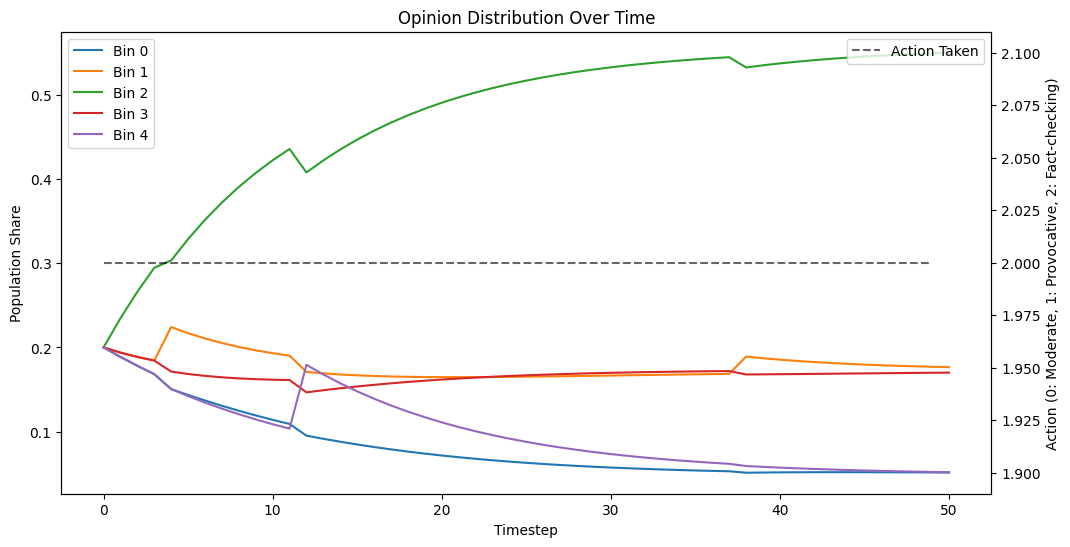

In [3]:
import numpy as np
import gym
from gym import spaces
import matplotlib.pyplot as plt
from stable_baselines3 import PPO

# ---- Step 1: Define Advanced Environment ---- #

class PolarizationEnv(gym.Env):
    """Advanced Environment for Polarization Dynamics with Feedback"""

    def __init__(self, population_size=1000):
        super(PolarizationEnv, self).__init__()

        self.population_size = population_size
        self.num_bins = 5  # Far left, left, center, right, far right

        self.opinion_distribution = np.ones(self.num_bins) / self.num_bins
        self.action_space = spaces.Discrete(3)
        self.observation_space = spaces.Box(low=0, high=1, shape=(self.num_bins,), dtype=np.float32)

        self.inertia = 0.85
        self.influence_strength = 0.1
        self.external_shock_prob = 0.05

        self.history = []
        self.actions_taken = []

    def step(self, action):
        self._apply_action(action)
        self._simulate_opinion_shift()
        self._external_shock()

        polarization_index = np.var(self.opinion_distribution)
        reward = -polarization_index

        done = False
        info = {"polarization_index": polarization_index}

        self.history.append(self.opinion_distribution.copy())
        self.actions_taken.append(action)

        return self.opinion_distribution.astype(np.float32), reward, done, info

    def reset(self):
        self.opinion_distribution = np.ones(self.num_bins) / self.num_bins
        self.history = [self.opinion_distribution.copy()]
        self.actions_taken = []
        return self.opinion_distribution.astype(np.float32)

    def render(self, mode='human'):
        plt.figure(figsize=(8, 4))
        plt.bar(range(self.num_bins), self.opinion_distribution)
        plt.xlabel('Ideological Position')
        plt.ylabel('Population Share')
        plt.title('Opinion Distribution')
        plt.show()

    def render_history(self):
        history = np.array(self.history)
        plt.figure(figsize=(12, 6))

        # Plot opinion distribution
        for i in range(self.num_bins):
            plt.plot(history[:, i], label=f'Bin {i}')
        plt.xlabel('Timestep')
        plt.ylabel('Population Share')
        plt.title('Opinion Distribution Over Time')
        plt.legend()

        # Plot actions taken
        plt.twinx()
        plt.plot(self.actions_taken, color='black', linestyle='--', alpha=0.6, label='Action Taken')
        plt.ylabel('Action (0: Moderate, 1: Provocative, 2: Fact-checking)')
        plt.legend(loc='upper right')

        plt.show()

    def _apply_action(self, action):
        if action == 0:  # Moderate messaging
            self.shift_target = 2
            self.shift_intensity = 0.02
        elif action == 1:  # Provocative messaging
            self.shift_target = np.random.choice([0, 4])
            self.shift_intensity = 0.07
        elif action == 2:  # Fact-checking campaign
            self.shift_target = 2
            self.shift_intensity = 0.04

    def _simulate_opinion_shift(self):
        new_distribution = self.opinion_distribution * self.inertia
        peer_influence = np.convolve(self.opinion_distribution, [0.25, 0.5, 0.25], mode='same')
        new_distribution += peer_influence * self.influence_strength
        shift = np.zeros(self.num_bins)
        shift[self.shift_target] = self.shift_intensity
        new_distribution += shift
        self.opinion_distribution = new_distribution / np.sum(new_distribution)

    def _external_shock(self):
        if np.random.rand() < self.external_shock_prob:
            shock_target = np.random.choice(self.num_bins)
            shock_intensity = np.random.uniform(0.02, 0.1)
            self.opinion_distribution[shock_target] += shock_intensity
            self.opinion_distribution /= np.sum(self.opinion_distribution)


# ---- Step 2: Train Agent ---- #

env = PolarizationEnv()
model = PPO('MlpPolicy', env, verbose=1)
model.learn(total_timesteps=30000)
model.save("ppo_polarization_v2")

# ---- Step 3: Test Agent and Visualize ---- #

obs = env.reset()
for _ in range(50):
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, done, info = env.step(action)
    print(f"Reward: {reward:.4f} | Polarization Index: {info['polarization_index']:.4f} | Action: {action}")

env.render_history()

# ---- Step 4: Run Fixed Strategies ---- #

def run_fixed_strategy(env, fixed_action, steps=50):
    obs = env.reset()
    for _ in range(steps):
        obs, reward, done, info = env.step(fixed_action)
        print(f"Reward: {reward:.4f} | Polarization Index: {info['polarization_index']:.4f} | Action: {fixed_action}")
    env.render_history()

print("\nRunning Always Moderate Strategy (Action 0)...")
run_fixed_strategy(env, fixed_action=0)

print("\nRunning Always Provocative Strategy (Action 1)...")
run_fixed_strategy(env, fixed_action=1)

print("\nRunning Always Fact-checking Strategy (Action 2)...")
run_fixed_strategy(env, fixed_action=2)


1. Trained Agent (PPO): actions are oscillating, so the agent is alternating
strategies. Plus opinion distribution fluctuates storngly with noticeable cycles. The agent seems to "chase" the distribution
2. Always Moderate (Action 0): action line is constant at 0. Population smoothly converges to center (Bin2). Very stable dynamics.
3. Always Provocative (Action 1): action constant at 1. Bin 4 rises quickly and dominates. Strong polarization effect: extremes are amplified while center bins decrease.
4. Always Fact-checking (Action 2): action constant at 2. Population slowly drifts toward the center, similar to moderate messaging, but slightly faster or stronger centralization than "always moderate"

So in 1. (PPO-trained agent graph), you can observe adaptive behavior and feedback loops: the agent does not pick a fixed strategy, instead it oscillates between actions (moderate, provocative, fact-checking) over time.  The beautiful part: feedback loop in action. Agent acts-> environment change. Environment changes->agent changes strategy. Agent strategy changes->environment changes again. This loop causes the oscillation you see: the system doesn't settle into a stable point. Instead, it enters a dynamic equilibrium or what complexity science calls an "attractor cycle" or "limit cycle". This is common in systems where decisions affect uncertainties. Decisions that shape distributions feed back into future uncertainties and strategies: this is the simulated evidence of that! But.. why it happens? In RL, especially PPO, the agent optimizes short term + expected future reward but because the environment is dynamic, future rewards depend on how its own actions have shaped the environment. So instead of converging to a static policy, it learns cyclical behaviors that adapt to the self-created fluctuations. This is common in political campaing strategies, stock market trading bots and complex adaptive systems.

In summary:
The agent's actions change the environment. These changes feed back and make previous strategies less effetive. The agent oscillates between strategies to adapt to this evolving landscape. This is an example of adaptive policy in a decision-dependent stochastic environment.

In 2. (Always Moderate) we have smooth stabilization. It returns moderate shift intensity (0.02), peer influence (smooths population movements) and inertia (opinions resisti quick changes). Why? Moderate messagin continously reinforces central consensus but does so gently, respecting population inertia (no aggressive changes, less volatility). Moderate policies lead to gradual convergence toward central opinions.

In 3. (Always provocative) we notice sharp polarization. Shift intensity is higher (0.07). The action targets extremes randomly every step (Bin 0 and Bin 4). Without moderation no force pulls back from the extremes. Peer influence reinforce clustering at the edges.

In 4. (Always Fact-checking), we notice stabilization, faster than moderate. Action targets Bin 2 (center) like moderate messaging but intensity is higher (0.04 vs 0.02). Why? it combats misinformation or extreme drift. It's an active stabilizer. It behaves like an assertive centripetal force.

This model captures real-world dynamics of ideological communication.




Streaming output truncated to the last 5000 lines.
new_distribution shape: (5,)
opinion_distribution shape: (5,)
peer_influence shape: (5,)
new_distribution shape: (5,)
opinion_distribution shape: (5,)
peer_influence shape: (5,)
new_distribution shape: (5,)
opinion_distribution shape: (5,)
peer_influence shape: (5,)
new_distribution shape: (5,)
opinion_distribution shape: (5,)
peer_influence shape: (5,)
new_distribution shape: (5,)
opinion_distribution shape: (5,)
peer_influence shape: (5,)
new_distribution shape: (5,)
opinion_distribution shape: (5,)
peer_influence shape: (5,)
new_distribution shape: (5,)
opinion_distribution shape: (5,)
peer_influence shape: (5,)
new_distribution shape: (5,)
opinion_distribution shape: (5,)
peer_influence shape: (5,)
new_distribution shape: (5,)
opinion_distribution shape: (5,)
peer_influence shape: (5,)
new_distribution shape: (5,)
opinion_distribution shape: (5,)
peer_influence shape: (5,)
new_distribution shape: (5,)
opinion_distribution shape: (5

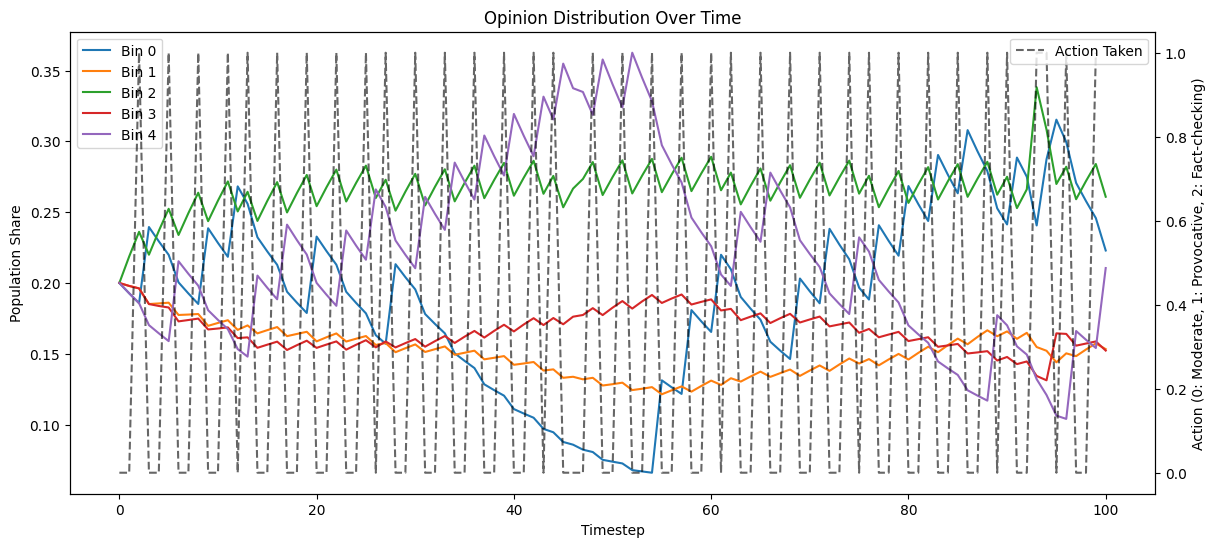

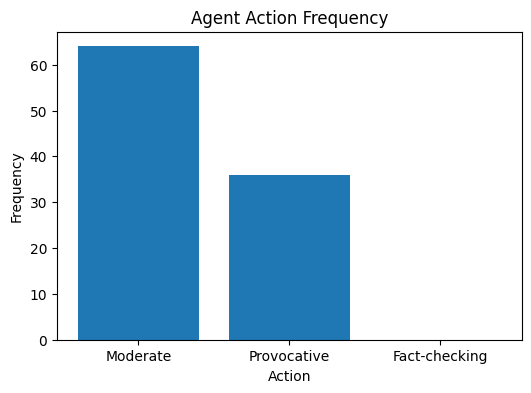

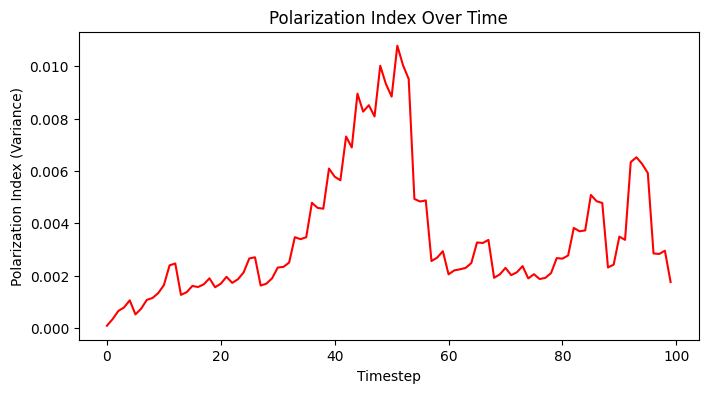

In [4]:
import numpy as np
import gym
from gym import spaces
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from collections import Counter

# ---- Step 1: Define Advanced Environment ---- #

class PolarizationEnv(gym.Env):
    """Advanced Environment for Polarization Dynamics with Feedback"""

    def __init__(self, population_size=1000):
        super(PolarizationEnv, self).__init__()

        self.population_size = population_size
        self.num_bins = 5  # Far left, left, center, right, far right

        self.opinion_distribution = np.ones(self.num_bins) / self.num_bins
        self.action_space = spaces.Discrete(3)
        self.observation_space = spaces.Box(low=0, high=1, shape=(self.num_bins,), dtype=np.float32)

        self.inertia = 0.85
        self.influence_strength = 0.1
        self.external_shock_prob = 0.05

        self.history = []
        self.actions_taken = []
        self.polarization_index_history = []

    def step(self, action):
        self._apply_action(action)
        self._simulate_opinion_shift()
        self._external_shock()

        polarization_index = np.var(self.opinion_distribution)
        reward = -polarization_index

        done = False
        info = {"polarization_index": polarization_index}

        self.history.append(self.opinion_distribution.copy())
        self.actions_taken.append(int(action))
        self.polarization_index_history.append(polarization_index)

        return self.opinion_distribution.astype(np.float32), reward, done, info

    def reset(self):
        self.opinion_distribution = np.ones(self.num_bins) / self.num_bins
        self.history = [self.opinion_distribution.copy()]
        self.actions_taken = []
        self.polarization_index_history = []
        return self.opinion_distribution.astype(np.float32)

    def render(self, mode='human'):
        plt.figure(figsize=(8, 4))
        plt.bar(range(self.num_bins), self.opinion_distribution)
        plt.xlabel('Ideological Position')
        plt.ylabel('Population Share')
        plt.title('Opinion Distribution')
        plt.show()

    def render_history(self):
        history = np.array(self.history)
        plt.figure(figsize=(14, 6))

        # Plot opinion distribution
        for i in range(self.num_bins):
            plt.plot(history[:, i], label=f'Bin {i}')
        plt.xlabel('Timestep')
        plt.ylabel('Population Share')
        plt.title('Opinion Distribution Over Time')
        plt.legend()

        # Plot actions taken
        plt.twinx()
        plt.plot(self.actions_taken, color='black', linestyle='--', alpha=0.6, label='Action Taken')
        plt.ylabel('Action (0: Moderate, 1: Provocative, 2: Fact-checking)')
        plt.legend(loc='upper right')

        plt.show()

    def plot_action_frequency(self):
        action_counts = Counter(self.actions_taken)
        # Get unique actions and their frequencies, ensuring all actions are represented
        actions = list(range(self.action_space.n))  # Get all possible actions (0, 1, 2)
        counts = [action_counts.get(action, 0) for action in actions]  # Get frequency, default to 0 if not present

        plt.figure(figsize=(6, 4))
        plt.bar(actions, counts, tick_label=['Moderate', 'Provocative', 'Fact-checking'])
        plt.xlabel('Action')
        plt.ylabel('Frequency')
        plt.title('Agent Action Frequency')
        plt.show()

    def plot_polarization_index(self):
        plt.figure(figsize=(8, 4))
        plt.plot(self.polarization_index_history, color='red')
        plt.xlabel('Timestep')
        plt.ylabel('Polarization Index (Variance)')
        plt.title('Polarization Index Over Time')
        plt.show()

    def _apply_action(self, action):
        if action == 0:  # Moderate messaging
            self.shift_target = 2
            self.shift_intensity = 0.02
        elif action == 1:  # Provocative messaging
            self.shift_target = int(np.random.choice([0, 4]))
            self.shift_intensity = 0.07
        elif action == 2:  # Fact-checking campaign
            self.shift_target = 2
            self.shift_intensity = 0.04

    def _simulate_opinion_shift(self):
        new_distribution = self.opinion_distribution * self.inertia
        print(f'opinion_distribution shape: {self.opinion_distribution.shape}')
        peer_influence = np.convolve(self.opinion_distribution, [0.25, 0.5, 0.25], mode='same')
        print(f'peer_influence shape: {peer_influence.shape}')
        print(f'new_distribution shape: {new_distribution.shape}')
        new_distribution += peer_influence * self.influence_strength
        shift = np.zeros(self.num_bins)
        shift[self.shift_target] = self.shift_intensity
        new_distribution += shift
        self.opinion_distribution = new_distribution / np.sum(new_distribution)

    def _external_shock(self):
        if np.random.rand() < self.external_shock_prob:
            shock_target = np.random.choice(self.num_bins)
            shock_intensity = np.random.uniform(0.02, 0.1)
            self.opinion_distribution[shock_target] += shock_intensity
            self.opinion_distribution /= np.sum(self.opinion_distribution)


# ---- Step 2: Train Agent ---- #

env = PolarizationEnv()
model = PPO('MlpPolicy', env, verbose=1)
model.learn(total_timesteps=200000)
model.save("ppo_polarization_v2")

# ---- Step 3: Test Agent and Visualize ---- #

obs = env.reset()
for _ in range(100):
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, done, info = env.step(action)
    print(f"Reward: {reward:.4f} | Polarization Index: {info['polarization_index']:.4f} | Action: {action}")

# Visualizations
env.render_history()
env.plot_action_frequency()
env.plot_polarization_index()


Agent action frequency: Moderate (~60 times), Provocative (~40 times), Fact-checking (0 times). So, the agent finds moderate messaging safer (reduces polarization). Occasionally "spices it up" with provocative actions, maybe to steer certain bins. It avoids fact-checking entirely, perhaps because it does not perceive additional benefit over moderate messaging in this environment setup.

Polarization Index Over Time: starts near zero (fully norm distribution), gradually increases over time, peacks around 0.014, then slightly dips and stabilizes with fluctuations. So, moderate actions slow polarization, but occasional provocative actions keep it fluctuating.

Running experiment 1/5


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Running experiment 2/5
Running experiment 3/5
Running experiment 4/5
Running experiment 5/5


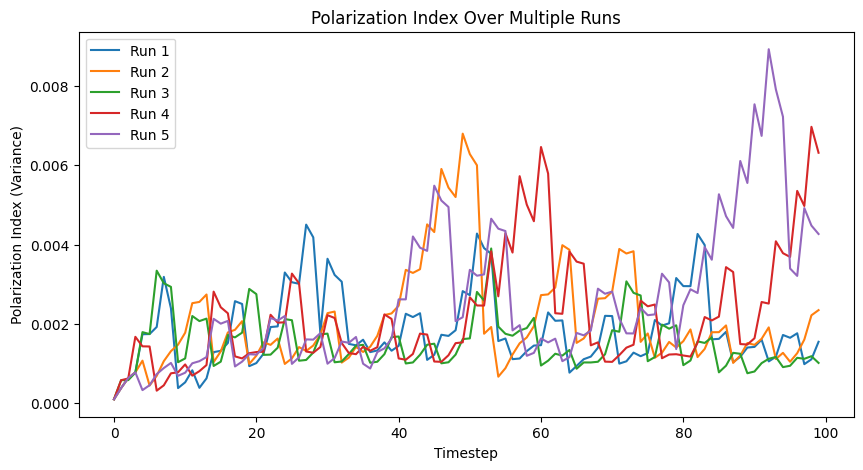

Average Polarization Index: 0.0026
Action Entropy: 0.6730


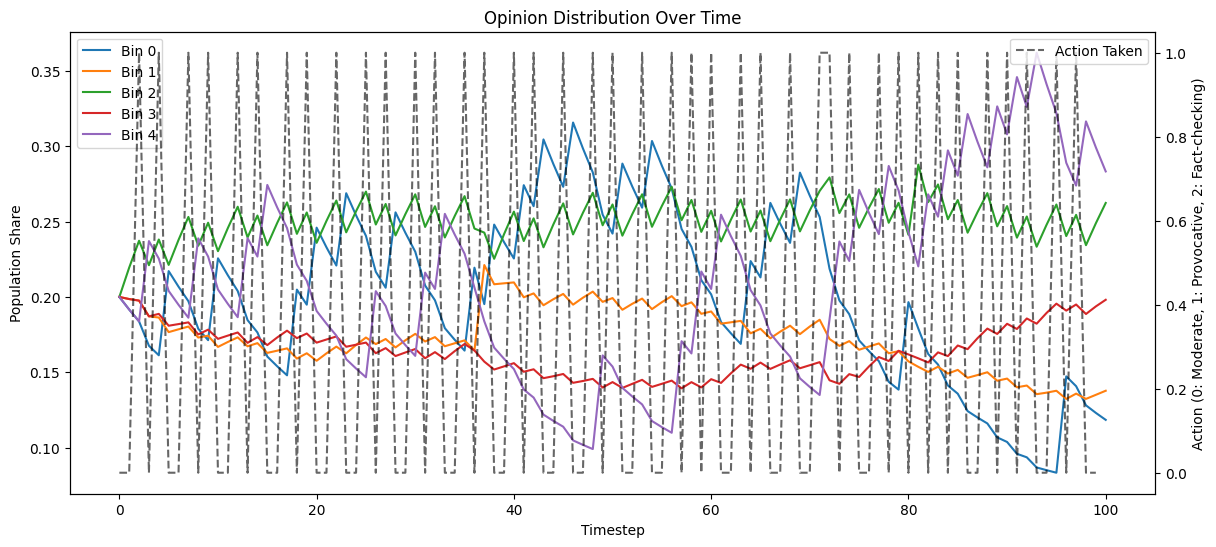

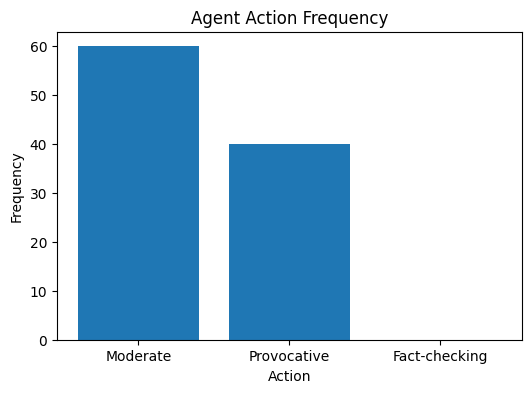

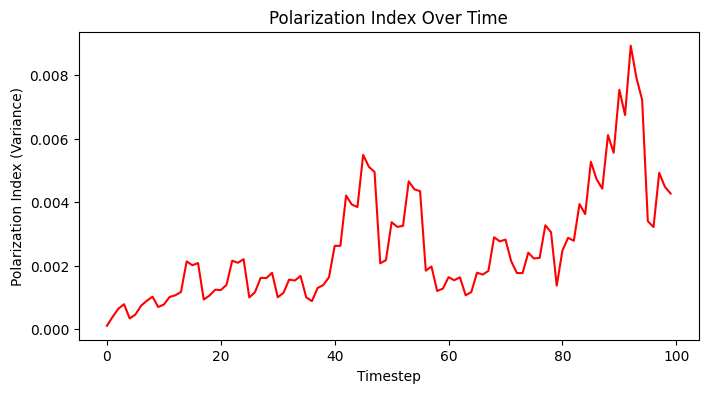

In [7]:
from collections import Counter
from scipy.stats import entropy # Import the entropy function

# ---- Step 1: Define Advanced Environment ---- #

class PolarizationEnv(gym.Env):
    """Advanced Environment for Polarization Dynamics with Feedback"""

    def __init__(self, population_size=1000):
        super(PolarizationEnv, self).__init__()

        self.population_size = population_size
        self.num_bins = 5  # Far left, left, center, right, far right

        self.opinion_distribution = np.ones(self.num_bins) / self.num_bins
        self.action_space = spaces.Discrete(3)
        self.observation_space = spaces.Box(low=0, high=1, shape=(self.num_bins,), dtype=np.float32)

        self.inertia = 0.85
        self.influence_strength = 0.1
        self.external_shock_prob = 0.05

        self.history = []
        self.actions_taken = []
        self.polarization_index_history = []

    def step(self, action):
        action = int(action)  # Ensure action is scalar integer
        self._apply_action(action)
        self._simulate_opinion_shift()
        self._external_shock()

        polarization_index = np.var(self.opinion_distribution)
        reward = -polarization_index

        done = False
        info = {"polarization_index": polarization_index}

        self.history.append(self.opinion_distribution.copy())
        self.actions_taken.append(action)
        self.polarization_index_history.append(polarization_index)

        return self.opinion_distribution.astype(np.float32), reward, done, info

    def reset(self):
        self.opinion_distribution = np.ones(self.num_bins) / self.num_bins
        self.history = [self.opinion_distribution.copy()]
        self.actions_taken = []
        self.polarization_index_history = []
        return self.opinion_distribution.astype(np.float32)

    def render(self, mode='human'):
        plt.figure(figsize=(8, 4))
        plt.bar(range(self.num_bins), self.opinion_distribution)
        plt.xlabel('Ideological Position')
        plt.ylabel('Population Share')
        plt.title('Opinion Distribution')
        plt.show()

    def render_history(self):
        history = np.array(self.history)
        plt.figure(figsize=(14, 6))

        # Plot opinion distribution
        for i in range(self.num_bins):
            plt.plot(history[:, i], label=f'Bin {i}')
        plt.xlabel('Timestep')
        plt.ylabel('Population Share')
        plt.title('Opinion Distribution Over Time')
        plt.legend()

        # Plot actions taken
        plt.twinx()
        plt.plot(self.actions_taken, color='black', linestyle='--', alpha=0.6, label='Action Taken')
        plt.ylabel('Action (0: Moderate, 1: Provocative, 2: Fact-checking)')
        plt.legend(loc='upper right')

        plt.show()

    def plot_action_frequency(self):
        action_counts = Counter(self.actions_taken)
        # Get unique actions and their frequencies, ensuring all actions are represented
        actions = list(range(self.action_space.n))  # Get all possible actions (0, 1, 2)
        counts = [action_counts.get(action, 0) for action in actions]  # Get frequency, default to 0 if not present

        plt.figure(figsize=(6, 4))
        # Use actions for x-axis to align with tick_labels
        plt.bar(actions, counts, tick_label=['Moderate', 'Provocative', 'Fact-checking'])
        plt.xlabel('Action')
        plt.ylabel('Frequency')
        plt.title('Agent Action Frequency')
        plt.show()

    def plot_polarization_index(self):
        plt.figure(figsize=(8, 4))
        plt.plot(self.polarization_index_history, color='red')
        plt.xlabel('Timestep')
        plt.ylabel('Polarization Index (Variance)')
        plt.title('Polarization Index Over Time')
        plt.show()

    def average_polarization_index(self):
        return np.mean(self.polarization_index_history)

    def action_entropy(self):
        action_counts = Counter(self.actions_taken)
        total = sum(action_counts.values())
        if total == 0:
            return 0.0
        probabilities = [count / total for count in action_counts.values()]
        return entropy(probabilities)

    def _apply_action(self, action):
        if action == 0:  # Moderate messaging
            self.shift_target = 2
            self.shift_intensity = 0.02
        elif action == 1:  # Provocative messaging
            self.shift_target = int(np.random.choice([0, 4]))
            self.shift_intensity = 0.07
        elif action == 2:  # Fact-checking campaign
            self.shift_target = 2
            self.shift_intensity = 0.04

    def _simulate_opinion_shift(self):
        new_distribution = self.opinion_distribution * self.inertia
        kernel_length = min(len(self.opinion_distribution), 3)
        kernel = np.ones(kernel_length) / kernel_length
        peer_influence = np.convolve(self.opinion_distribution, kernel, mode='same')
        new_distribution += peer_influence * self.influence_strength
        shift = np.zeros(self.num_bins)
        shift[self.shift_target] = self.shift_intensity
        new_distribution += shift
        total = np.sum(new_distribution)
        if total == 0:
            self.opinion_distribution = np.ones(self.num_bins) / self.num_bins
        else:
            self.opinion_distribution = new_distribution / total

    def _external_shock(self):
        if np.random.rand() < self.external_shock_prob:
            shock_target = np.random.choice(self.num_bins)
            shock_intensity = np.random.uniform(0.02, 0.1)
            self.opinion_distribution[shock_target] += shock_intensity
            total = np.sum(self.opinion_distribution)
            if total == 0:
                self.opinion_distribution = np.ones(self.num_bins) / self.num_bins
            else:
                self.opinion_distribution /= total


# ---- Step 2: Train Agent ---- #

def train_and_run(env, timesteps=200000, test_steps=100):
    model = PPO('MlpPolicy', env, verbose=0)
    model.learn(total_timesteps=timesteps)

    obs = env.reset()
    for _ in range(test_steps):
        action, _states = model.predict(obs, deterministic=True)
        obs, reward, done, info = env.step(action)

    return env

# ---- Step 3: Multiple Runs for Stability ---- #

all_polarization_histories = []
num_runs = 5

for run in range(num_runs):
    print(f"Running experiment {run + 1}/{num_runs}")
    env = PolarizationEnv()
    trained_env = train_and_run(env)
    all_polarization_histories.append(trained_env.polarization_index_history)

# Overlay polarization indices
plt.figure(figsize=(10, 5))
for idx, history in enumerate(all_polarization_histories):
    plt.plot(history, label=f'Run {idx + 1}')
plt.xlabel('Timestep')
plt.ylabel('Polarization Index (Variance)')
plt.title('Polarization Index Over Multiple Runs')
plt.legend()
plt.show()

# ---- Step 4: Analyze Last Run ---- #

print(f"Average Polarization Index: {trained_env.average_polarization_index():.4f}")
print(f"Action Entropy: {trained_env.action_entropy():.4f}")

trained_env.render_history()
trained_env.plot_action_frequency()
trained_env.plot_polarization_index()


Interpretation of results:
1. Average polarization Index (=0.0026) is the average variance of the opinion distribution over time. While the agent adopts predominantly moderate messaging, polarization incrementally increases over time suggesting that moderate messaging alone is insufficient to counteract the natural drift towards ideological segregation in the absence of stronger corrective actions.

2. Action entropy (=0.6730) is the Shannon entropy of agent's action choices:
  * 0.0 = fully deterministic (always one action)
  * ~1.0 = evenly mixed strategy (random or exploratory)
So, entropy = 0.6730 indicates the agent is partially diversified: mostly moderate actions, some provocations, never fact-checking. The agent is not locked into a single strategy. It adapts and oscillates between moderate and provocative choices. This matches the behavior visble in the action frequency chart and timeline overlays. In conclusion, the agent demonstrates partial policy diversity with an entropy of 0.6730, indicating adaptive oscillation between moderate and provocative messaging. However, the consistent omission of fact-checking suggests the agent perceives limited reward potential from this strategy in the current environment configuration.

